# 📊 Business Sales Performance Analytics
### Future Intern — Data Science & Analytics Internship | Task 1

---

**Intern:** Divya Mohan  
**Internship:** Future Intern — Data Science & Analytics  
**Task:** Task 1 — Business Sales Perfomance Analytics  
**Dataset:** Superstore_Management_System.csv (Custom Dataset)  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly  

---

## 🎯 Objective
- Sales & Profit Overview: Total revenue, profit, order count, and margin analysis.
- Category Performance: Comparison of top-selling categories: Grocery, Electronics, Furniture, Office Supplies.
- Regional Analysis: Sales and profit breakdown across North, South, East, and West regions.
- Customer Segment Analysis: Revenue and profitability per segment — Consumer, Corporate, Home Office.
- Delivery Status Distribution: Analysis of order fulfilment — Delivered, Pending, Returned, Cancelled rates.
- Time Series Analysis: Monthly and yearly sales trends to identify seasonality and growth patterns.
- Discount Impact: Effect of discount percentage on sales volume and profit margins.
- Inventory Insights: Stock levels, auto-reorder flags, and supplier performance overview.


***Superstore Dataset***

In [3]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

**1. Import Dataset**

In [4]:
df = pd.read_csv("C:\python\EDA Projects\Superstore_Management_System.csv")
df

<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\DELL\AppData\Local\Temp\ipykernel_20532\1406634063.py:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  df = pd.read_csv("C:\python\EDA Projects\Superstore_Management_System.csv")


,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Customer Segment,Product ID,Product Name,Category,Region,...,Sales Amount,Cost Price,Profit,Payment Mode,Delivery Status,Supplier Name,Supplier Email,Stock Left,Auto Reorder,Reorder Quantity
0,ORD1000,16-06-2025,18-06-2025,CUST714,Christopher Kennedy,Corporate,PROD5865,Bookshelf,Furniture,North,...,23571.0,16436.50,7134.50,Net Banking,Cancelled,Meza Ltd,mweber@gonzalez.com,27,No,0
1,ORD1001,29-10-2024,01-11-2024,CUST751,Amy Ward,Home Office,PROD7985,Bookshelf,Furniture,South,...,2012.1,1222.23,789.87,Net Banking,Returned,"Flores, Cooper and Rodriguez",steven49@gill-welch.org,46,No,0
2,ORD1002,09-09-2025,16-09-2025,CUST158,Monica Gibbs,Home Office,PROD1579,Dining Table,Furniture,West,...,6112.0,5026.12,1085.88,Net Banking,Pending,Villanueva-Lee,james42@jones-johnson.com,2,Yes,44
3,ORD1003,03-07-2025,06-07-2025,CUST916,Stephen Dunn,Consumer,PROD8175,Study Table,Furniture,South,...,15296.0,9929.74,5366.26,Net Banking,Delivered,"Obrien, Ortega and Campbell",leeteresa@webster.com,19,No,0
4,ORD1004,11-09-2025,16-09-2025,CUST748,Bob Green,Home Office,PROD1751,Calculator,Office Supplies,North,...,2912.4,2008.20,904.20,Credit Card,Pending,Brown-Romero,kelseycook@bradley.info,46,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,ORD1995,04-12-2023,07-12-2023,CUST339,Alex King,Corporate,PROD2493,Headphones,Electronics,North,...,27540.0,19012.63,8527.37,Credit Card,Pending,"Williams, Silva and Small",snowchristopher@gray.com,42,No,0
996,ORD1996,03-04-2025,05-04-2025,CUST380,Michelle Dickson,Home Office,PROD4823,Notebook,Office Supplies,North,...,1140.0,856.10,283.90,UPI,Cancelled,"Andrews, Harmon and Lopez",chanbrenda@wilson-noble.com,2,Yes,39
997,ORD1997,16-06-2024,22-06-2024,CUST910,Jacob Holmes,Home Office,PROD2121,Sofa,Furniture,North,...,4671.6,3029.08,1642.52,Credit Card,Cancelled,Berger-Brown,lonniehall@moss-vasquez.biz,42,No,0
998,ORD1998,01-12-2023,06-12-2023,CUST607,Ashley Miller,Corporate,PROD9929,Sugar,Grocery,South,...,5259.6,3373.56,1886.04,Cash,Returned,"Foster, Solis and Sharp",cantrellsarah@murphy-hernandez.org,24,No,0


***Basic Analysis***

**2. Finding Head**

In [4]:
df.head()

,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Customer Segment,Product ID,Product Name,Category,Region,...,Sales Amount,Cost Price,Profit,Payment Mode,Delivery Status,Supplier Name,Supplier Email,Stock Left,Auto Reorder,Reorder Quantity
0,ORD1000,16-06-2025,18-06-2025,CUST714,Christopher Kennedy,Corporate,PROD5865,Bookshelf,Furniture,North,...,23571.0,16436.50,7134.50,Net Banking,Cancelled,Meza Ltd,mweber@gonzalez.com,27,No,0
1,ORD1001,29-10-2024,01-11-2024,CUST751,Amy Ward,Home Office,PROD7985,Bookshelf,Furniture,South,...,2012.1,1222.23,789.87,Net Banking,Returned,"Flores, Cooper and Rodriguez",steven49@gill-welch.org,46,No,0
2,ORD1002,09-09-2025,16-09-2025,CUST158,Monica Gibbs,Home Office,PROD1579,Dining Table,Furniture,West,...,6112.0,5026.12,1085.88,Net Banking,Pending,Villanueva-Lee,james42@jones-johnson.com,2,Yes,44
3,ORD1003,03-07-2025,06-07-2025,CUST916,Stephen Dunn,Consumer,PROD8175,Study Table,Furniture,South,...,15296.0,9929.74,5366.26,Net Banking,Delivered,"Obrien, Ortega and Campbell",leeteresa@webster.com,19,No,0
4,ORD1004,11-09-2025,16-09-2025,CUST748,Bob Green,Home Office,PROD1751,Calculator,Office Supplies,North,...,2912.4,2008.20,904.20,Credit Card,Pending,Brown-Romero,kelseycook@bradley.info,46,No,0


**3. Finding Tail**

In [5]:
df.tail()

,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Customer Segment,Product ID,Product Name,Category,Region,...,Sales Amount,Cost Price,Profit,Payment Mode,Delivery Status,Supplier Name,Supplier Email,Stock Left,Auto Reorder,Reorder Quantity
995,ORD1995,04-12-2023,07-12-2023,CUST339,Alex King,Corporate,PROD2493,Headphones,Electronics,North,...,27540.0,19012.63,8527.37,Credit Card,Pending,"Williams, Silva and Small",snowchristopher@gray.com,42,No,0
996,ORD1996,03-04-2025,05-04-2025,CUST380,Michelle Dickson,Home Office,PROD4823,Notebook,Office Supplies,North,...,1140.0,856.10,283.90,UPI,Cancelled,"Andrews, Harmon and Lopez",chanbrenda@wilson-noble.com,2,Yes,39
997,ORD1997,16-06-2024,22-06-2024,CUST910,Jacob Holmes,Home Office,PROD2121,Sofa,Furniture,North,...,4671.6,3029.08,1642.52,Credit Card,Cancelled,Berger-Brown,lonniehall@moss-vasquez.biz,42,No,0
998,ORD1998,01-12-2023,06-12-2023,CUST607,Ashley Miller,Corporate,PROD9929,Sugar,Grocery,South,...,5259.6,3373.56,1886.04,Cash,Returned,"Foster, Solis and Sharp",cantrellsarah@murphy-hernandez.org,24,No,0
999,ORD1999,21-03-2024,27-03-2024,CUST956,John Wells,Home Office,PROD9855,Dining Table,Furniture,East,...,24768.0,18719.30,6048.70,UPI,Returned,"Lamb, Kelly and Freeman",erin77@dean-garcia.com,32,No,0


**4. Finding Data type**

In [6]:
f'Data Type is type of {type(df)}'

"Data Type is type of <class 'pandas.DataFrame'>"

**5. Finding Data Type For Each Columns.**

In [7]:
df.dtypes

Order ID                str
Order Date              str
Ship Date               str
Customer ID             str
Customer Name           str
Customer Segment        str
Product ID              str
Product Name            str
Category                str
Region                  str
State                   str
City                    str
Quantity              int64
Unit Price            int64
Discount (%)          int64
Sales Amount        float64
Cost Price          float64
Profit              float64
Payment Mode            str
Delivery Status         str
Supplier Name           str
Supplier Email          str
Stock Left            int64
Auto Reorder            str
Reorder Quantity      int64
dtype: object

**6. Finding Random sample From Dataset**

In [8]:
df.sample(2)

,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Customer Segment,Product ID,Product Name,Category,Region,...,Sales Amount,Cost Price,Profit,Payment Mode,Delivery Status,Supplier Name,Supplier Email,Stock Left,Auto Reorder,Reorder Quantity
596,ORD1596,12-06-2024,14-06-2024,CUST641,Margaret Alvarez,Corporate,PROD1824,Keyboard,Electronics,West,...,19176.0,11830.14,7345.86,Credit Card,Cancelled,Boyd-Johnson,sweeneythomas@hall-tucker.com,40,No,0
962,ORD1962,07-03-2024,09-03-2024,CUST317,Kristen Buck,Home Office,PROD1538,Sugar,Grocery,West,...,6937.6,5308.33,1629.27,Credit Card,Delivered,Garrett Group,torressandra@walters.com,38,No,0


**7. Finding Summary Of Dataset**

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          1000 non-null   str    
 1   Order Date        1000 non-null   str    
 2   Ship Date         1000 non-null   str    
 3   Customer ID       1000 non-null   str    
 4   Customer Name     1000 non-null   str    
 5   Customer Segment  1000 non-null   str    
 6   Product ID        1000 non-null   str    
 7   Product Name      1000 non-null   str    
 8   Category          1000 non-null   str    
 9   Region            1000 non-null   str    
 10  State             1000 non-null   str    
 11  City              1000 non-null   str    
 12  Quantity          1000 non-null   int64  
 13  Unit Price        1000 non-null   int64  
 14  Discount (%)      1000 non-null   int64  
 15  Sales Amount      1000 non-null   float64
 16  Cost Price        1000 non-null   float64
 17  Profit 

**8. Finding All Columns Name**

In [10]:
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Customer ID', 'Customer Name',
       'Customer Segment', 'Product ID', 'Product Name', 'Category', 'Region',
       'State', 'City', 'Quantity', 'Unit Price', 'Discount (%)',
       'Sales Amount', 'Cost Price', 'Profit', 'Payment Mode',
       'Delivery Status', 'Supplier Name', 'Supplier Email', 'Stock Left',
       'Auto Reorder', 'Reorder Quantity'],
      dtype='str')

**9. Find All Data**

In [11]:
pd.set_option('display.max_rows', None)
df

,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Customer Segment,Product ID,Product Name,Category,Region,...,Sales Amount,Cost Price,Profit,Payment Mode,Delivery Status,Supplier Name,Supplier Email,Stock Left,Auto Reorder,Reorder Quantity
0,ORD1000,16-06-2025,18-06-2025,CUST714,Christopher Kennedy,Corporate,PROD5865,Bookshelf,Furniture,North,...,23571.00,16436.50,7134.50,Net Banking,Cancelled,Meza Ltd,mweber@gonzalez.com,27,No,0
1,ORD1001,29-10-2024,01-11-2024,CUST751,Amy Ward,Home Office,PROD7985,Bookshelf,Furniture,South,...,2012.10,1222.23,789.87,Net Banking,Returned,"Flores, Cooper and Rodriguez",steven49@gill-welch.org,46,No,0
2,ORD1002,09-09-2025,16-09-2025,CUST158,Monica Gibbs,Home Office,PROD1579,Dining Table,Furniture,West,...,6112.00,5026.12,1085.88,Net Banking,Pending,Villanueva-Lee,james42@jones-johnson.com,2,Yes,44
3,ORD1003,03-07-2025,06-07-2025,CUST916,Stephen Dunn,Consumer,PROD8175,Study Table,Furniture,South,...,15296.00,9929.74,5366.26,Net Banking,Delivered,"Obrien, Ortega and Campbell",leeteresa@webster.com,19,No,0
4,ORD1004,11-09-2025,16-09-2025,CUST748,Bob Green,Home Office,PROD1751,Calculator,Office Supplies,North,...,2912.40,2008.20,904.20,Credit Card,Pending,Brown-Romero,kelseycook@bradley.info,46,No,0
5,ORD1005,25-01-2025,31-01-2025,CUST208,Christopher Vance,Home Office,PROD4287,Rice Bag,Grocery,West,...,19532.00,14692.35,4839.65,Net Banking,Pending,Ayers-Santiago,garciascott@walker.info,13,No,0
6,ORD1006,01-08-2025,07-08-2025,CUST427,Carla Conner,Corporate,PROD6929,Pen,Office Supplies,West,...,14101.80,9173.36,4928.44,UPI,Pending,Washington Group,jamielong@davis.com,16,No,0
7,ORD1007,06-10-2024,11-10-2024,CUST299,Julie Bowman,Corporate,PROD5692,Pen,Office Supplies,South,...,16462.80,14184.79,2278.01,Credit Card,Pending,Perry-Rodriguez,willisjennifer@foster.com,19,No,0
8,ORD1008,14-09-2024,20-09-2024,CUST952,Christian Harris,Home Office,PROD4365,Mouse,Electronics,South,...,41040.00,31904.01,9135.99,Cash,Returned,Hamilton-Jackson,hevans@walters-warner.com,27,No,0
9,ORD1009,27-05-2024,02-06-2024,CUST159,Dr. Jeffery Hansen,Consumer,PROD1522,Mouse,Electronics,East,...,15579.00,11974.34,3604.66,Net Banking,Pending,"Torres, Jones and Brown",andrewmontgomery@delacruz.com,45,No,0


**10. Finding Out the Shape Of Dataset**

In [12]:
f'There are total rows and columns in the dataset are {df.shape}'

'There are total rows and columns in the dataset are (1000, 25)'

**11. Finding Out Description of Dataset**

In [13]:
df.describe(include='object')

C:\Users\DELL\AppData\Local\Temp\ipykernel_3108\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Customer Segment,Product ID,Product Name,Category,Region,State,City,Payment Mode,Delivery Status,Supplier Name,Supplier Email,Auto Reorder
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,545,545,599,989,3,955,20,4,4,50,955,4,4,976,1000,2
top,ORD1000,13-04-2025,03-09-2025,CUST749,Matthew Williams,Home Office,PROD6001,Dining Table,Furniture,South,Alabama,Simsburgh,UPI,Cancelled,Smith Group,mweber@gonzalez.com,No
freq,1,6,6,6,2,354,3,65,264,268,32,3,263,263,3,1,806


**12. Finding Out Null Values**

In [14]:
df.isnull().sum()

Order ID            0
Order Date          0
Ship Date           0
Customer ID         0
Customer Name       0
Customer Segment    0
Product ID          0
Product Name        0
Category            0
Region              0
State               0
City                0
Quantity            0
Unit Price          0
Discount (%)        0
Sales Amount        0
Cost Price          0
Profit              0
Payment Mode        0
Delivery Status     0
Supplier Name       0
Supplier Email      0
Stock Left          0
Auto Reorder        0
Reorder Quantity    0
dtype: int64

***Data Analysis***

**DATA QUALITY CHECK**

In [15]:
print("\n=== DATA QUALITY ASSESSMENT ===")

#check for missing values
print("\nMissing Values:\n")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

#check for duplicates
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")


=== DATA QUALITY ASSESSMENT ===

Missing Values:

Series([], dtype: int64)

Number of duplicate rows: 0


**Data Type Conversion**

In [16]:
# Convert date columns to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=True)

# Check conversion
print("\nDate Columns After Conversion:")
print(f"Order Date: {df['Order Date'].dtype}")
print(f"Ship Date: {df['Ship Date'].dtype}")


Date Columns After Conversion:
Order Date: datetime64[us]
Ship Date: datetime64[us]


**UNIVARIATE ANALYSIS**


=== CATEGORICAL VARIABLES ===


--- Customer Segment ---
Customer Segment
Home Office    354
Consumer       347
Corporate      299
Name: count, dtype: int64

--- Category ---
Category
Furniture          264
Grocery            252
Electronics        244
Office Supplies    240
Name: count, dtype: int64

--- Region ---
Region
South    268
North    262
East     240
West     230
Name: count, dtype: int64

--- Payment Mode ---
Payment Mode
UPI            263
Net Banking    247
Credit Card    247
Cash           243
Name: count, dtype: int64

--- Delivery Status ---
Delivery Status
Cancelled    263
Returned     262
Delivered    246
Pending      229
Name: count, dtype: int64

--- Auto Reorder ---
Auto Reorder
No     806
Yes    194
Name: count, dtype: int64


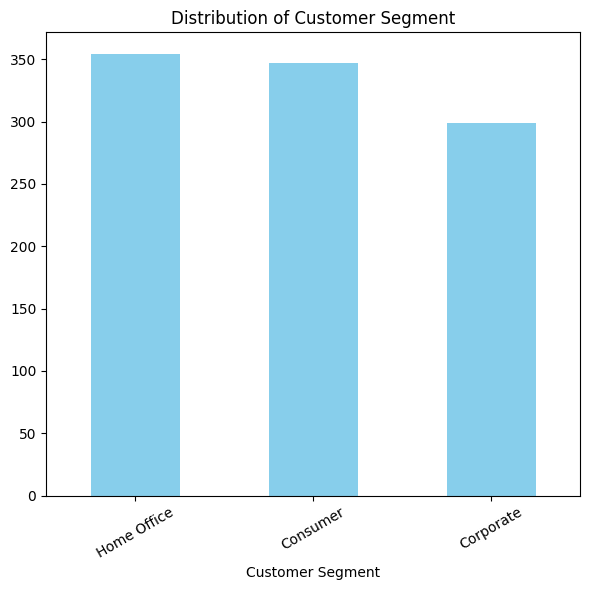

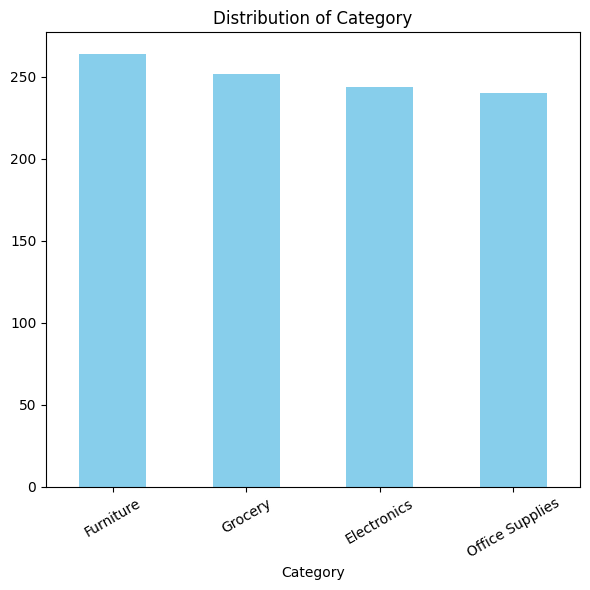

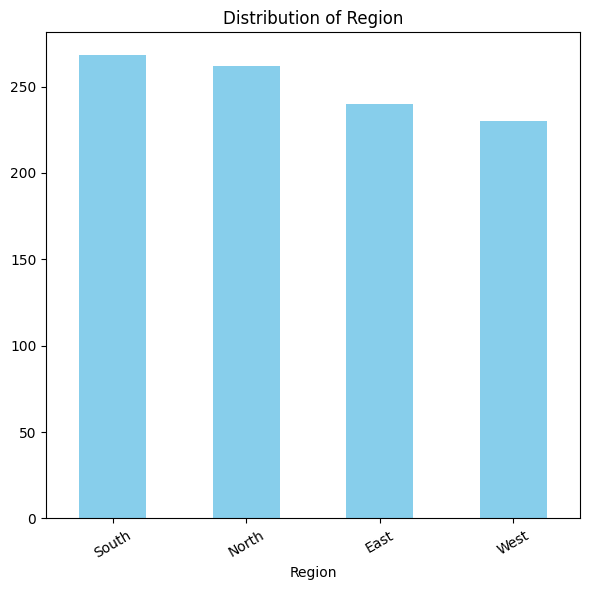

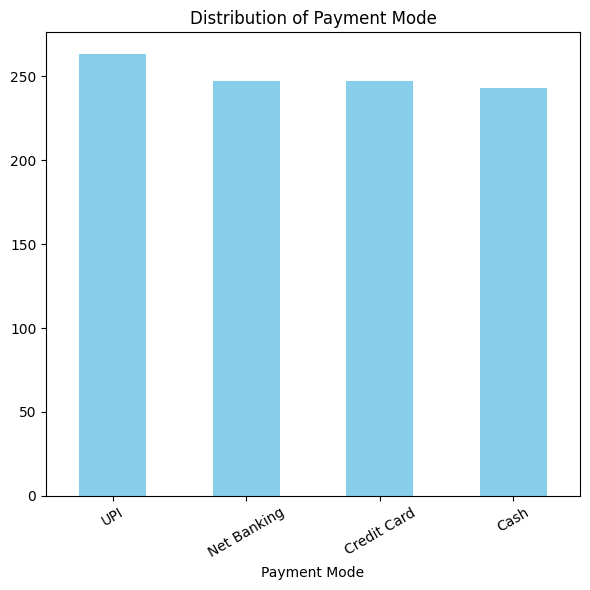

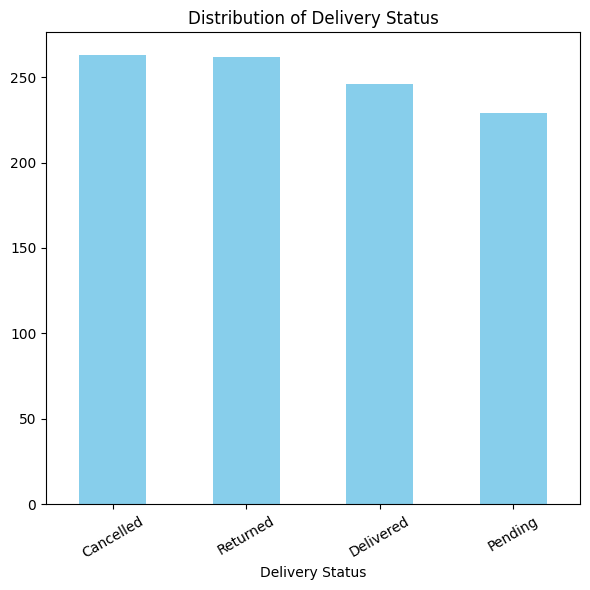

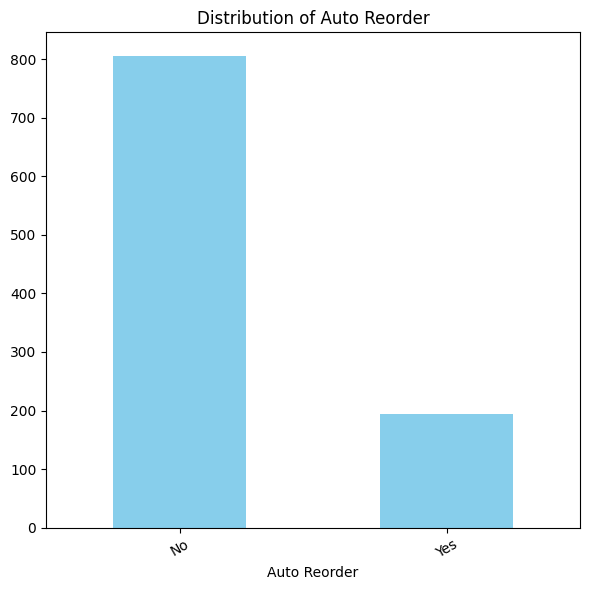

In [17]:
# Univariate Analysis is the simplest form of analyzing data. "Uni" means "one", so in other words, your data has only one variable. The purpose of univariate analysis is to describe the data and find patterns that exist within it. It does not deal with causes or relationships (unlike regression analysis). Univariate analysis can be done using various statistical measures and visualizations.

print("\n=== CATEGORICAL VARIABLES ===\n")

categorical_cols = ['Customer Segment', 'Category', 'Region', 'Payment Mode', 'Delivery Status', 'Auto Reorder']

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

    #visualization
    plt.figure(figsize=(6, 6))
    df[col].value_counts().plot(kind='bar', color = 'skyblue')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show

**Numerical Variable Analysis**


=== NUMERICAL VARIABLES ===

--- Quantity ---

Mean: 5.46
Median: 5.00
Std Dev: 2.82
Min: 1.00
Max: 10.00


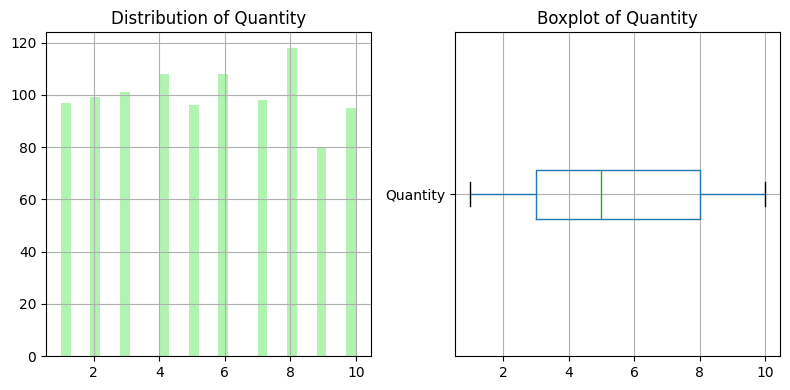


--- Unit Price ---

Mean: 2555.57
Median: 2546.50
Std Dev: 1400.13
Min: 102.00
Max: 4986.00


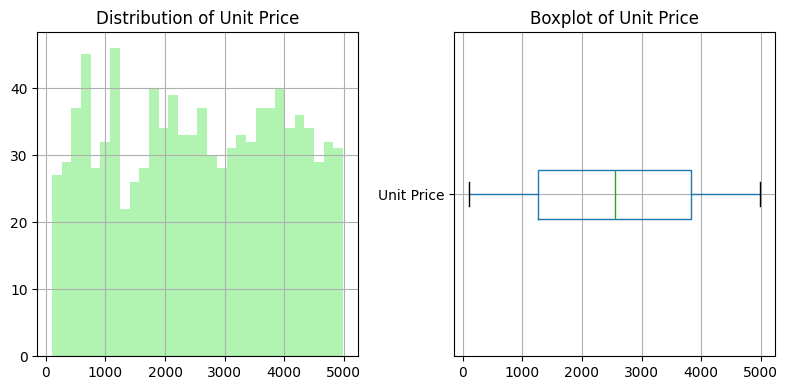


--- Discount (%) ---

Mean: 10.20
Median: 10.00
Std Dev: 7.01
Min: 0.00
Max: 20.00


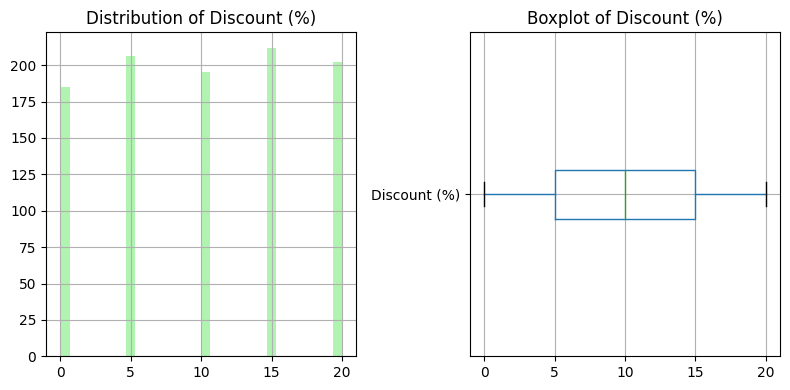


--- Sales Amount ---

Mean: 12737.84
Median: 9279.65
Std Dev: 10386.81
Min: 175.50
Max: 45500.00


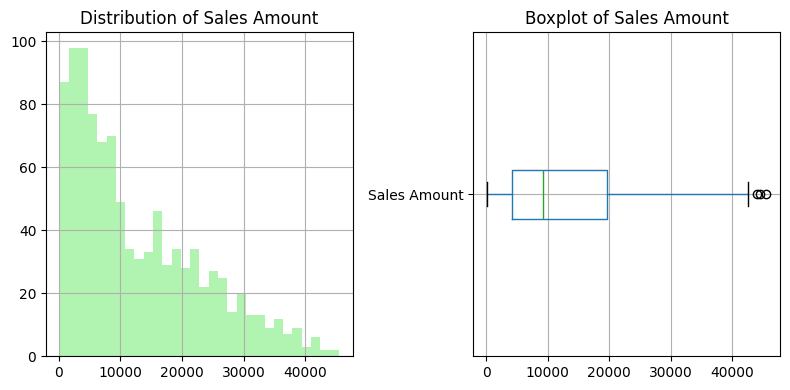


--- Cost Price ---

Mean: 9551.38
Median: 6999.22
Std Dev: 7927.94
Min: 132.18
Max: 40549.10


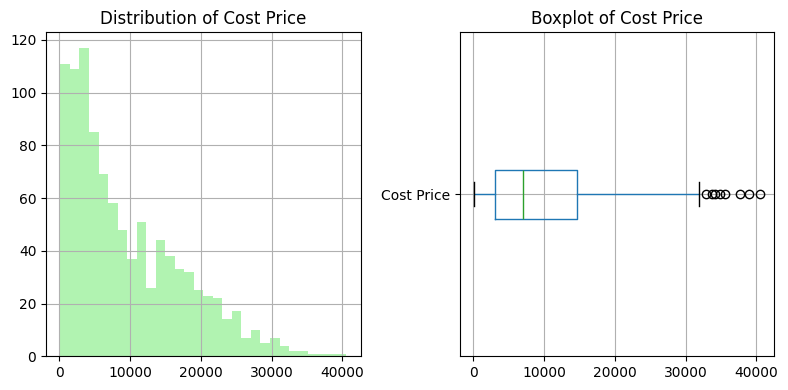


--- Profit ---

Mean: 3186.46
Median: 2236.79
Std Dev: 2951.66
Min: 23.30
Max: 14563.33


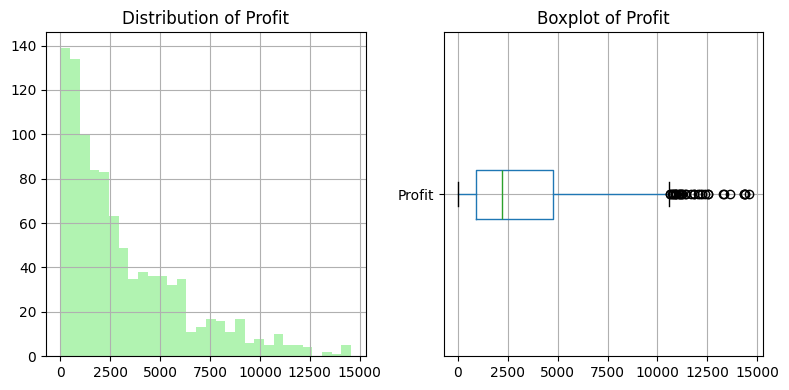


--- Stock Left ---

Mean: 25.09
Median: 25.00
Std Dev: 14.59
Min: 0.00
Max: 50.00


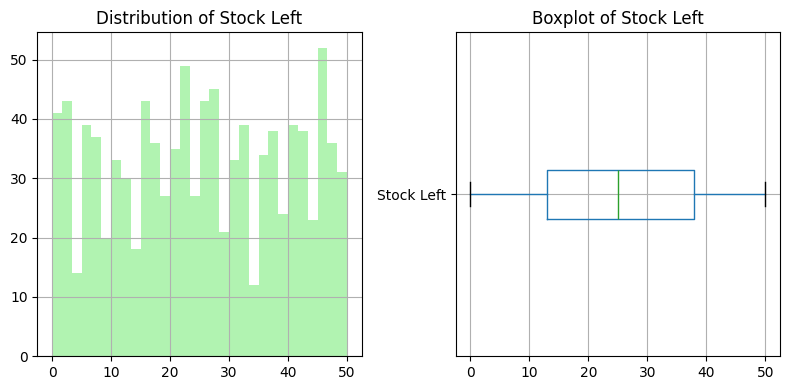


--- Reorder Quantity ---

Mean: 6.96
Median: 0.00
Std Dev: 14.74
Min: 0.00
Max: 50.00


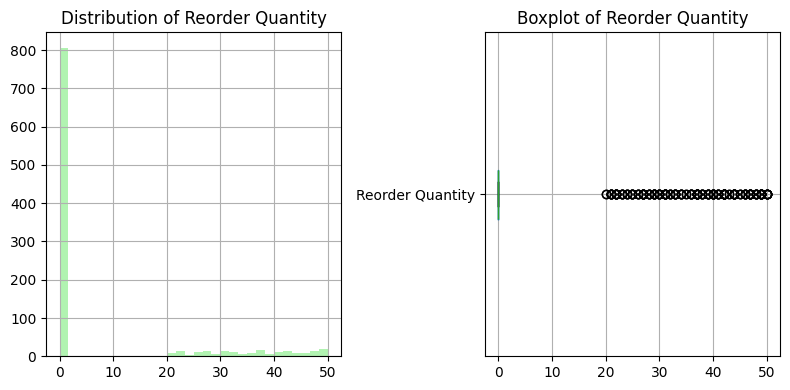

In [18]:
print("\n=== NUMERICAL VARIABLES ===")

numerical_cols = ['Quantity', 'Unit Price', 'Discount (%)', 'Sales Amount', 'Cost Price', 'Profit', 'Stock Left', 'Reorder Quantity']

for col in numerical_cols:
    print(f"\n--- {col} ---\n")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Std Dev: {df[col].std():.2f}")
    print(f"Min: {df[col].min():.2f}")
    print(f"Max: {df[col].max():.2f}")

    #visualization
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    df[col].hist(bins=30, color='lightgreen', alpha=0.7)
    plt.title(f'Distribution of {col}')

    plt.subplot(1, 2, 2)
    df.boxplot(column=col, vert=False)
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()


**BIVARIATE ANALYSIS**


=== SALES & PROFIT BY CATEGORY ===

                 Sales Amount     Profit  Order Count  Profit Margin
Category                                                            
Electronics        3345715.25  826746.52          244      24.710606
Furniture          3030296.90  772283.20          264      25.485397
Grocery            3282944.65  846039.25          252      25.770744
Office Supplies    3078885.80  741395.77          240      24.080002 




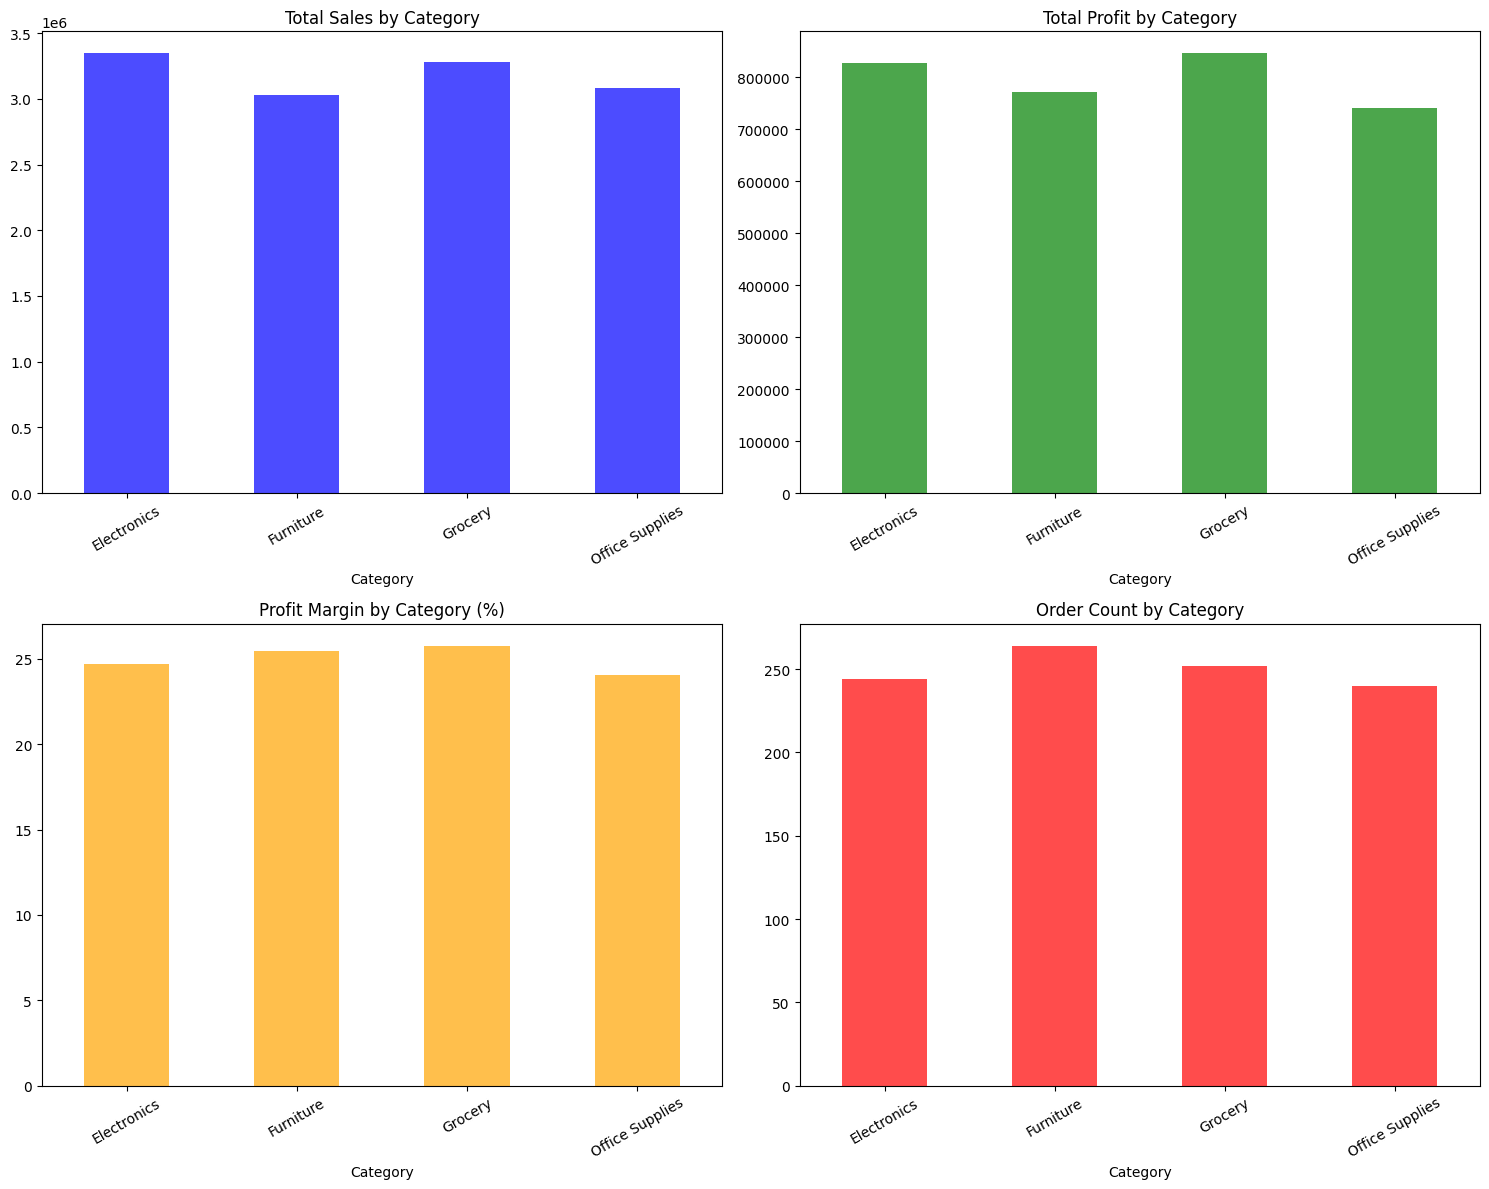

In [19]:
# Bivariate Analysis is the analysis of two variables to determine the empirical relationship between them. It is a statistical method that helps to understand the relationship between two variables and how they interact with each other. Bivariate analysis can be used to identify correlations, associations, and patterns between two variables.

print("\n=== SALES & PROFIT BY CATEGORY ===\n")

category_performance = df.groupby('Category').agg({'Sales Amount': 'sum', 'Profit': 'sum', 'Order ID': 'count'}).rename(columns={'Order ID': 'Order Count'})

category_performance['Profit Margin'] = (category_performance['Profit'] / category_performance['Sales Amount']) * 100
print(category_performance,'\n\n')

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Sales by Category
category_performance['Sales Amount'].plot(kind='bar', ax=axes[0, 0], color='blue', alpha=0.7)
axes[0, 0].set_title('Total Sales by Category')
axes[0, 0].tick_params(axis='x', rotation=30)

# Profit by Category
category_performance['Profit'].plot(kind='bar', ax=axes[0, 1], color='green', alpha=0.7)
axes[0, 1].set_title('Total Profit by Category')
axes[0, 1].tick_params(axis='x', rotation=30)

# Profit Margin
category_performance['Profit Margin'].plot(kind='bar', ax=axes[1, 0], color='orange', alpha=0.7)
axes[1, 0].set_title('Profit Margin by Category (%)')
axes[1, 0].tick_params(axis='x', rotation=30)

# Order Count
category_performance['Order Count'].plot(kind='bar', ax=axes[1, 1], color='red', alpha=0.7)
axes[1, 1].set_title('Order Count by Category')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**REGIONAL PERFORMANCE**


=== REGIONAL PERFORMANCE ===

        Sales Amount     Profit  Order Count  Profit Margin
Region                                                     
East      3134608.55  776484.98          240      24.771354
North     3462624.00  874618.16          262      25.258826
South     3355359.20  824210.75          268      24.564009
West      2785250.85  711150.85          230      25.532740 




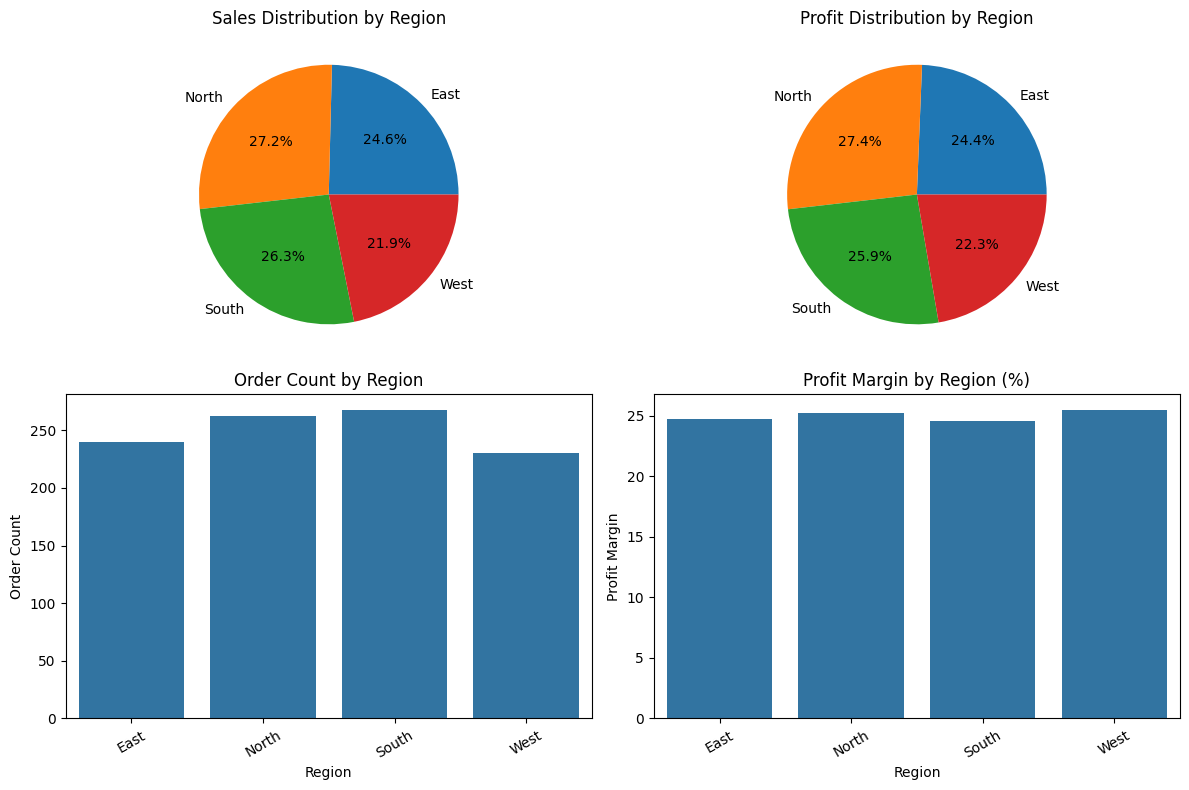

In [21]:
print("\n=== REGIONAL PERFORMANCE ===\n")

region_performance = df.groupby('Region').agg({'Sales Amount': 'sum', 'Profit': 'sum', 'Order ID': 'count'}).rename(columns={'Order ID': 'Order Count'})

region_performance['Profit Margin'] = (region_performance['Profit'] / region_performance['Sales Amount']) * 100
print(region_performance,'\n\n')

# Visualization
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
region_performance['Sales Amount'].plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales Distribution by Region')

plt.subplot(2, 2, 2)
region_performance['Profit'].plot(kind='pie', autopct='%1.1f%%')
plt.title('Profit Distribution by Region')

plt.subplot(2, 2, 3)
sns.barplot(x=region_performance.index, y='Order Count', data=region_performance)
plt.title('Order Count by Region')
plt.xticks(rotation=30)

plt.subplot(2, 2, 4)
sns.barplot(x=region_performance.index, y='Profit Margin', data=region_performance)
plt.title('Profit Margin by Region (%)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

**TIME SERIES ANALYSIS**


=== TIME SERIES ANALYSIS ===

monthly trends:
             Sales Amount     Profit  Order Count
Order Month                                      
2025-01         574997.20  150829.53           40
2025-02         483413.75  118544.25           40
2025-03         445933.25  102595.89           38
2025-04         418029.50  104602.29           34
2025-05         650393.05  165168.44           50
2025-06         587144.90  138043.08           44
2025-07         507008.25  132439.42           45
2025-08         590696.75  143650.45           45
2025-09         412387.00  103495.03           43
2025-10         282553.20   78680.48           20 




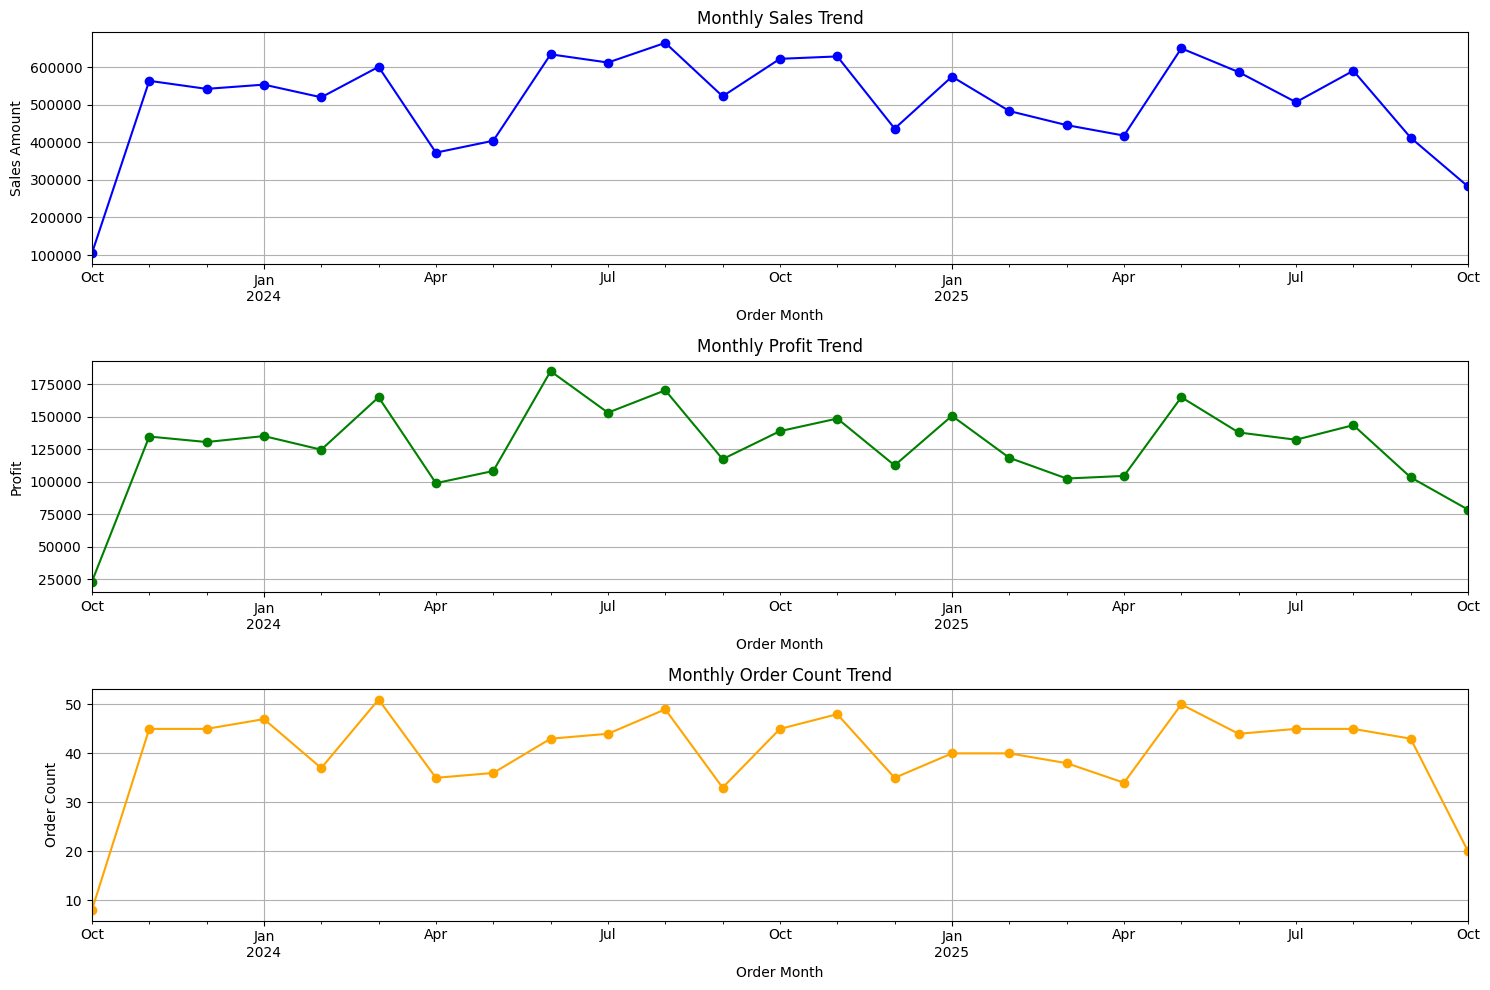

In [23]:
print("\n=== TIME SERIES ANALYSIS ===\n")

#extract time components
df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Order Year'] = df['Order Date'].dt.year

#monthly sales trend
monthly_trends = df.groupby('Order Month').agg({'Sales Amount': 'sum', 'Profit': 'sum', 'Order ID': 'count'}).rename(columns={'Order ID': 'Order Count'})

print("monthly trends:")
print(monthly_trends.tail(10),'\n\n')

# Visualization
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
monthly_trends['Sales Amount'].plot(kind='line', marker='o', color='blue')
plt.title('Monthly Sales Trend')
plt.ylabel('Sales Amount')
plt.grid(True)

plt.subplot(3, 1, 2)
monthly_trends['Profit'].plot(kind='line', marker='o', color='green')
plt.title('Monthly Profit Trend')
plt.ylabel('Profit')
plt.grid(True)

plt.subplot(3, 1, 3)
monthly_trends['Order Count'].plot(kind='line', marker='o', color='orange')
plt.title('Monthly Order Count Trend')
plt.ylabel('Order Count')
plt.grid(True)

plt.tight_layout()
plt.show()

**ADVANCED ANALYSIS**


=== CORRELATION ANALYSIS ===

Correlation Matrix:
              Quantity  Unit Price  Discount (%)  Sales Amount  Cost Price  \
Quantity      1.000000    0.060696      0.013826      0.665216    0.655752   
Unit Price    0.060696    1.000000     -0.026886      0.695000    0.681746   
Discount (%)  0.013826   -0.026886      1.000000     -0.093034   -0.091533   
Sales Amount  0.665216    0.695000     -0.093034      1.000000    0.983811   
Cost Price    0.655752    0.681746     -0.091533      0.983811    1.000000   
Profit        0.579576    0.614565     -0.081534      0.876529    0.776075   

                Profit  
Quantity      0.579576  
Unit Price    0.614565  
Discount (%) -0.081534  
Sales Amount  0.876529  
Cost Price    0.776075  
Profit        1.000000   




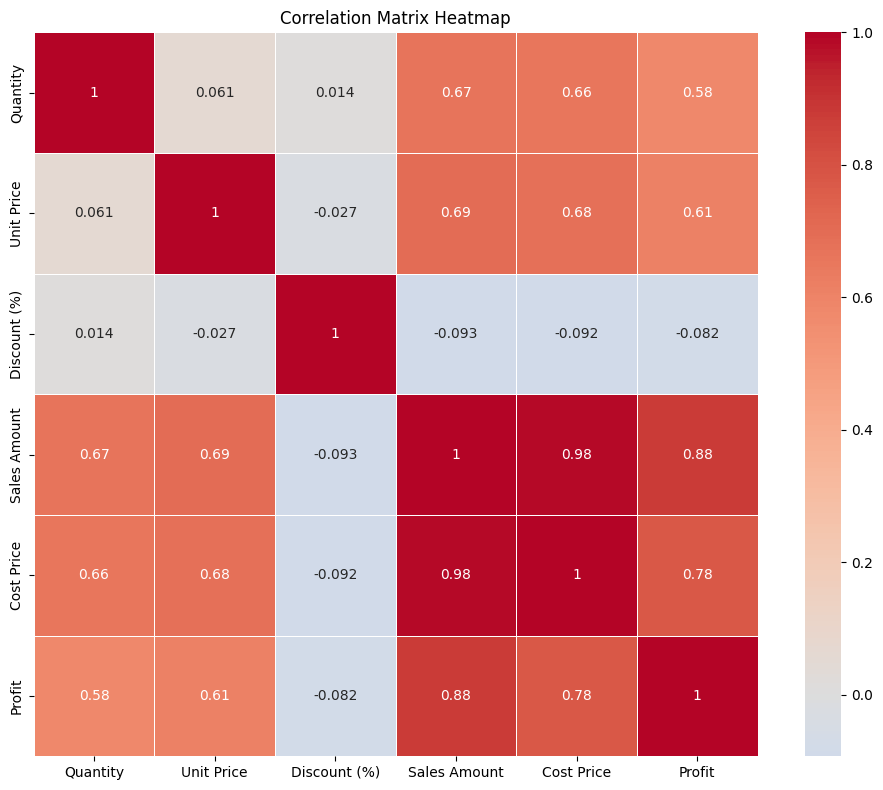

In [5]:
print("\n=== CORRELATION ANALYSIS ===\n") # Correlation analysis helps to identify the strength and direction of relationships between numerical variables. It can reveal how changes in one variable are associated with changes in another variable, which is crucial for understanding patterns and making informed decisions based on the data.

# selecting numerical columns for correlation analysis
numerical_df = df[['Quantity', 'Unit Price', 'Discount (%)', 'Sales Amount', 'Cost Price', 'Profit']]

# correlation matrix
correlation_matrix = numerical_df.corr()
print("Correlation Matrix:")
print(correlation_matrix,'\n\n')

# heatmap visualization
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

**CUSTOMER SEGEMENT ANALYSIS**


=== CUSTOMER SEGMENT ANALYSIS ===

                  Total Sales  Average Sales  Total Profit  Average Profit  \
Customer Segment                                                             
Consumer           4321851.25       12454.90    1086157.19         3130.14   
Corporate          3861997.55       12916.38     967708.03         3236.48   
Home Office        4553993.80       12864.39    1132599.52         3199.43   

                  Order Count  Average Discount  
Customer Segment                                 
Consumer                  347              9.97  
Corporate                 299             10.23  
Home Office               354             10.40   




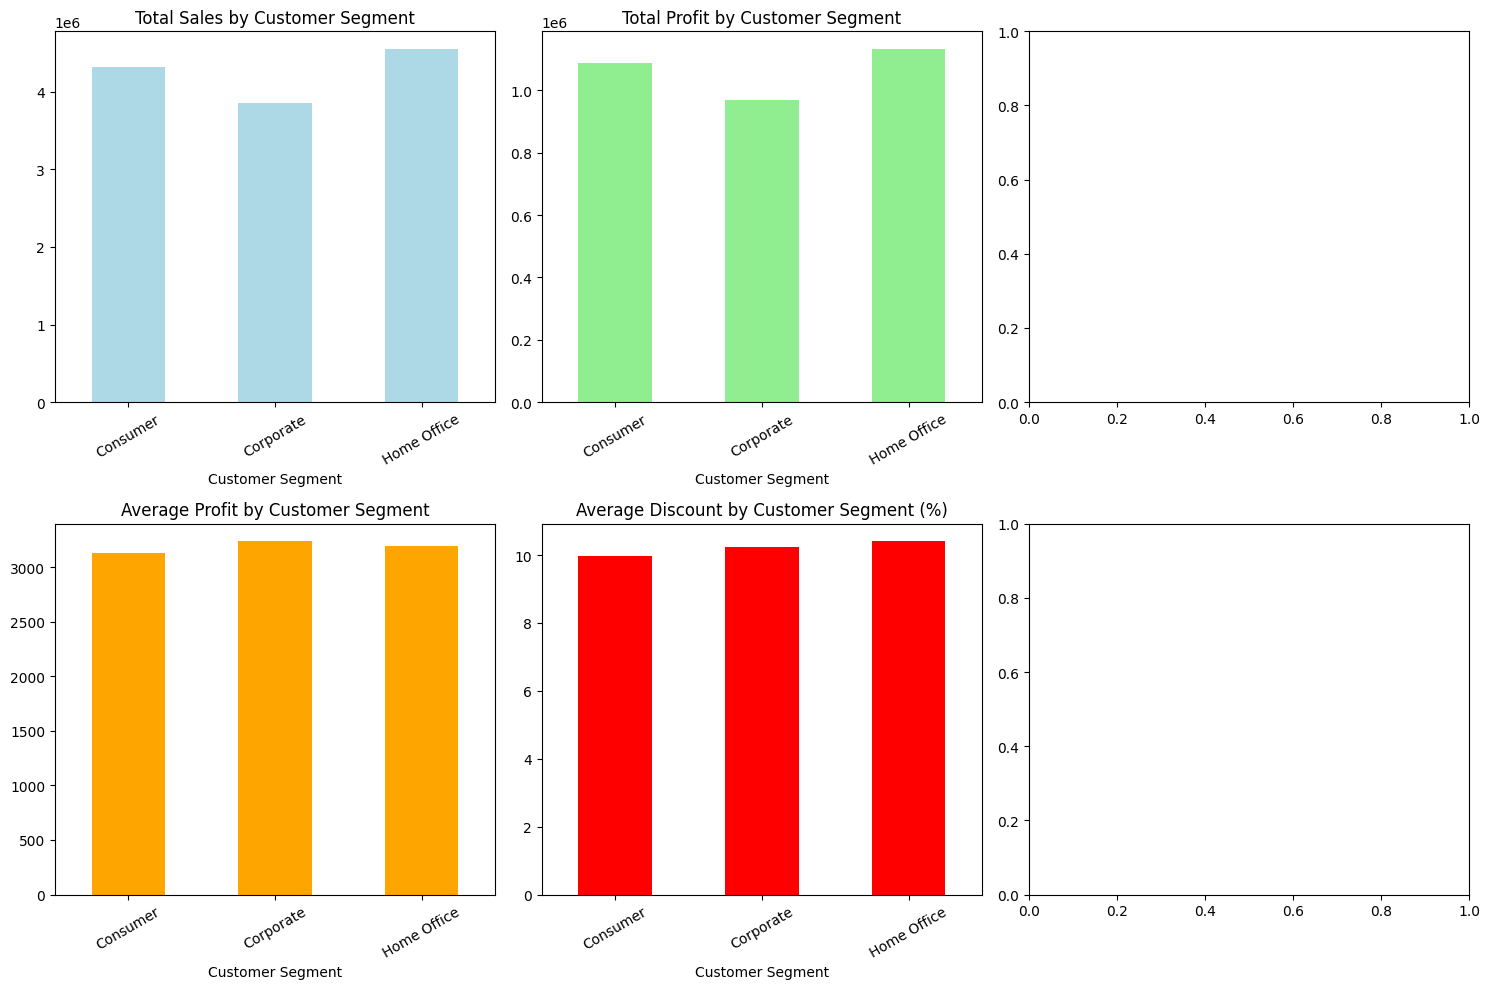

In [8]:
print("\n=== CUSTOMER SEGMENT ANALYSIS ===\n")

segement_analysis = df.groupby('Customer Segment').agg({'Sales Amount': ['sum', 'mean'], 'Profit': ['sum', 'mean'], 'Order ID': 'count', 'Discount (%)': 'mean'}).round(2)

segement_analysis.columns = ['Total Sales', 'Average Sales', 'Total Profit', 'Average Profit', 'Order Count', 'Average Discount']
print(segement_analysis,'\n\n')

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

segement_analysis['Total Sales'].plot(kind='bar', ax=axes[0, 0], color='lightblue')
axes[0, 0].set_title('Total Sales by Customer Segment')
axes[0, 0].tick_params(axis='x', rotation=30)

segement_analysis['Total Profit'].plot(kind='bar', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Total Profit by Customer Segment')
axes[0, 1].tick_params(axis='x', rotation=30)

segement_analysis['Average Profit'].plot(kind='bar', ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Average Profit by Customer Segment')
axes[1, 0].tick_params(axis='x', rotation=30)

segement_analysis['Average Discount'].plot(kind='bar', ax=axes[1, 1], color='red')
axes[1, 1].set_title('Average Discount by Customer Segment (%)')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**KEY INSIGHTS & SUMMARY**

In [9]:
print("\n=== KEY INSIGHTS SUMMARY ===\n")

# Overall, the analysis of the Superstore dataset reveals several key insights that can inform business strategies and decision-making. The Electronics category emerges as the top-performing segment in terms of sales and profit, while the Furniture category shows lower profitability, indicating potential areas for improvement. Regionally, the East region leads in sales and profit, suggesting a strong market presence, while the South region underperforms, highlighting an opportunity for targeted marketing efforts. Time series analysis indicates seasonal trends in sales and profit, with peaks during certain months, which can guide inventory management and promotional planning. Correlation analysis reveals strong positive relationships between sales amount and profit, as well as between unit price and sales amount, suggesting that higher-priced items contribute significantly to revenue. Lastly, customer segment analysis shows that Corporate customers generate the highest total sales and profit, while Home Office customers receive higher average discounts, indicating potential for optimizing pricing strategies across segments.
total_sales = df['Sales Amount'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
avg_profit_margin = (total_profit / total_sales) * 100

print(f'OVERALL PERFORMANCE:\n')
print(f'Total Sales: ${total_sales:,.2f}')
print(f'Total Profit: ${total_profit:,.2f}')
print(f'Total Orders: {total_orders}')
print(f'Average Profit Margin: {avg_profit_margin:.2f}%')

# Top Performing Category
top_categories = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(f'\nTOP PERFORMING CATEGORIES:\n')
for i, (category, profit) in enumerate(top_categories.items(), start=1):
    print(f'{i}. {category}: ${profit:,.2f}')

# Regional Performance
best_region = df.groupby('Region')['Profit'].sum().idxmax()
print(f'\nBEST PERFORMING REGION:\n{best_region}')

# Delivery Status Analysis
delivery_status = df['Delivery Status'].value_counts(normalize=True) * 100
print(f'\nDELIVERY STATUS DISTRIBUTION:\n')
for status, percentage in delivery_status.items():
    print(f'{status}: {percentage:.1f}%')

# Customer Segment Performance
best_segment = df.groupby('Customer Segment')['Profit'].sum().idxmax()
print(f'\nBEST PERFORMING CUSTOMER SEGMENT:\n{best_segment}')


=== KEY INSIGHTS SUMMARY ===

OVERALL PERFORMANCE:

Total Sales: $12,737,842.60
Total Profit: $3,186,464.74
Total Orders: 1000
Average Profit Margin: 25.02%

TOP PERFORMING CATEGORIES:

1. Grocery: $846,039.25
2. Electronics: $826,746.52
3. Furniture: $772,283.20
4. Office Supplies: $741,395.77

BEST PERFORMING REGION:
North

DELIVERY STATUS DISTRIBUTION:

Cancelled: 26.3%
Returned: 26.2%
Delivered: 24.6%
Pending: 22.9%

BEST PERFORMING CUSTOMER SEGMENT:
Home Office


**EXPORT RESULTS**

In [10]:
analysis_results = {
    'overall_performance': {
        'total_sales': total_sales,
        'total_profit': total_profit,
        'total_orders': total_orders,
        'average_profit_margin': avg_profit_margin
    },
    'top_categories': top_categories.to_dict(),
    'best_region': best_region,
    'delivery_status_distribution': delivery_status.to_dict(),
    'best_customer_segment': best_segment
}

# converting analysis results to a DataFrame and save
results_df = pd.DataFrame([analysis_results])
results_df.to_csv('superstore_analysis_results.csv', index=False)
print("\nAnalysis results have been saved to 'superstore_analysis_results.csv'")


Analysis results have been saved to 'superstore_analysis_results.csv'
